# 🤖 机器学习基础（Day 12）

> 本笔记是两门课程的"衔接"内容：上午吃透**线性回归 + 正规方程**（理论），下午掌握 **PyTorch 预备知识**（工具），把 Day11 的机器学习概念落地成可运行的代码。
>
> - **李宏毅《机器学习》第 4~9 讲**：线性回归基本概念 → 正规方程（解析解）→ sklearn 实战
> - **李沐《动手学深度学习 V2》6.1~18.3**：数据操作、数据预处理、线性代数、自动求导
>
> 📺 视频链接：
> - 李宏毅机器学习：https://www.bilibili.com/video/BV1RnikBvE8m
> - 李沐动手学深度学习（PyTorch 版）：https://www.bilibili.com/video/BV1EY6FBwE8P

**学习安排：**

**上午（3h）—— 线性回归与正规方程（李宏毅 第 4~9 讲）**

1. 线性回归基本概念：假设函数、代价函数 MSE
2. 正规方程（Normal Equation）：一步解出最优参数
3. 用 numpy 从零实现正规方程，求解多元一次方程
4. sklearn 的 LinearRegression 实战（带截距 vs 不带截距）

**下午（3h）—— PyTorch 预备知识（李沐 d2l 6.1~18.3）**

5. 数据操作：张量 Tensor 的创建、索引、运算、广播
6. 数据预处理：pandas 读 CSV、处理缺失值、one-hot 编码
7. 线性代数：向量/矩阵运算、按轴求和、范数
8. 自动求导：autograd 原理与 backward()

> ⚠️ **运行提示**：请从第一个代码单元格开始**按顺序**运行，后面的代码会用到前面定义好的变量与函数。

In [10]:
!pip install pandas torch scikit-learn matplotlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.linear_model import LinearRegression

# 让 matplotlib 能正常显示中文（Windows 常见字体）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False   # 让负号 "-" 正常显示

# 本笔记统一使用的颜色（与 Day11 风格一致）
蓝 = '#2b7bba'
橙 = '#e69f00'
灰 = '#999999'
红 = '#d62728'
绿 = '#2ca02c'

print("✓ 环境准备完成")
print("numpy", np.__version__, "| pandas", pd.__version__, "| torch", torch.__version__)

numpy 2.2.5 | pandas 2.3.3 | torch 2.14.0+cpu



# 🎓 第一部分：线性回归与正规方程（李宏毅 第 4~9 讲）

> 本部分对应 6 讲：
> - **第四讲**：线性回归的基本概念 1
> - **第五讲**：线性回归的基本概念 2
> - **第六讲**：正规方程介绍
> - **第七讲**：正规方程求解多元一次方程
> - **第八讲**：sklearn 中线性方程正规方程运算
> - **第九讲**：sklearn 带截距运算

## 1. 线性回归：最基础的机器学习模型

**回归（Regression）** 是"输出一个连续数值"的任务（Day11 讲过）。**线性回归（Linear Regression）** 是最简单的回归模型——它假设输出 $y$ 是输入特征 $x$ 的**线性组合**。

**一元线性回归**（只有一个特征 $x$）：

$$y = w \cdot x + b$$

- $w$ 是**权重（weight）**，也就是这条直线的斜率；
- $b$ 是**偏置（bias）**，也就是截距（直线与 y 轴的交点）；
- 我们要做的，就是**从数据里学出最合适的 $w$ 和 $b$**。

**多元线性回归**（多个特征 $x_1, x_2, \dots, x_n$）：

$$y = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^\top \mathbf{x} + b$$

> 一句话：**线性回归 = 用一条直线（或超平面）去拟合数据，让"预测值"尽量接近"真实值"。**

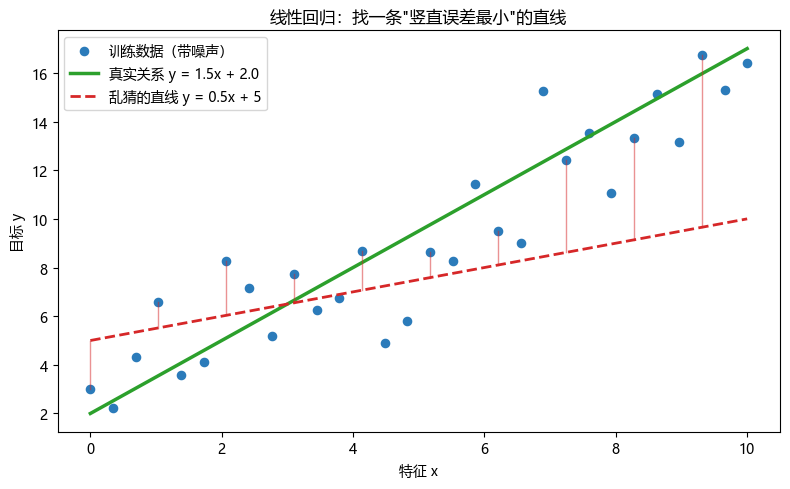

In [11]:
# ---- 一元线性回归：直观感受"用直线拟合数据" ----
np.random.seed(42)
X = np.linspace(0, 10, 30)
真实w, 真实b = 1.5, 2.0
y = 真实w * X + 真实b + np.random.randn(30) * 2   # 真实关系 + 噪声

# 一条"乱猜"的直线：w=0.5, b=5，明显拟合得很差
y_bad = 0.5 * X + 5

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X, y, color=蓝, s=35, label='训练数据（带噪声）')
ax.plot(X, 真实w * X + 真实b, color=绿, lw=2.5, label=f'真实关系 y = {真实w}x + {真实b}')
ax.plot(X, y_bad, color=红, lw=2, ls='--', label='乱猜的直线 y = 0.5x + 5')

# 画出"误差"：真实点到乱猜直线的竖直距离
for xi, yi, yi_hat in zip(X[::3], y[::3], y_bad[::3]):
    ax.plot([xi, xi], [yi, yi_hat], color=红, lw=1, alpha=0.5)

ax.set_xlabel('特征 x'); ax.set_ylabel('目标 y')
ax.set_title('线性回归：找一条"竖直误差最小"的直线')
ax.legend()
plt.tight_layout()
plt.show()

## 2. 代价函数：给这条直线"打分"

怎么判断一条直线好不好？看它**预测值和真实值差多少**。这就是**代价函数（cost function）**，最常用的是**均方误差 MSE**：

$$J(w, b) = \frac{1}{m}\sum_{i=1}^{m}\big(\hat y_i - y_i\big)^2 = \frac{1}{m}\sum_{i=1}^{m}\big((w x_i + b) - y_i\big)^2$$

- $m$ 是样本数量，$\hat y_i = w x_i + b$ 是预测值，$y_i$ 是真实值；
- **平方**让误差恒为正，且"大误差"被惩罚得更狠；
- 我们的目标就是：**找到让 $J(w,b)$ 最小的一组 $(w, b)$**。

> 这就是 Day11 讲的"训练三步曲"里 **Step 2 定义损失**。现在问题变成：怎么找最小值？
> 有两种思路——① **正规方程**（直接套公式，本讲主角）；② **梯度下降**（迭代逼近，视频后面的第 22~35 讲讲）。

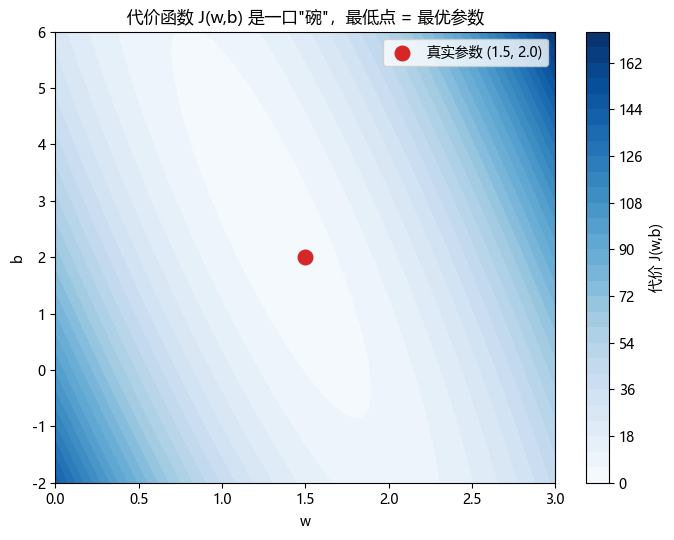

In [12]:
# ---- 代价函数 J(w,b) 是一口"碗"：最低点就是最优参数 ----
def 代价(w, b):
    return np.mean(((w * X + b) - y) ** 2)   # 复用上一个 cell 的 X、y

ws = np.linspace(0, 3, 100)
bs = np.linspace(-2, 6, 100)
W, B = np.meshgrid(ws, bs)
Z = np.array([[代价(w, b) for w in ws] for b in bs])

fig, ax = plt.subplots(figsize=(7, 5.5))
c = ax.contourf(W, B, Z, levels=30, cmap='Blues')
fig.colorbar(c, label='代价 J(w,b)')
ax.scatter([真实w], [真实b], color=红, s=110, zorder=5, label=f'真实参数 ({真实w}, {真实b})')
ax.set_xlabel('w'); ax.set_ylabel('b')
ax.set_title('代价函数 J(w,b) 是一口"碗"，最低点 = 最优参数')
ax.legend()
plt.tight_layout()
plt.show()

## 3. 正规方程（Normal Equation）：一步解出最优参数

代价函数 $J$ 是凸的（像上面那口"碗"），所以最小值在**导数等于 0** 的地方。我们可以直接对 $J$ 求导、令导数为 0，**解出解析解**——这个解就是**正规方程**：

$$\boldsymbol{\theta} = \big(\mathbf{X}^\top \mathbf{X}\big)^{-1} \mathbf{X}^\top \mathbf{y}$$

其中：
- $\mathbf{X}$ 是样本矩阵，形状 $(m, n)$：$m$ 个样本、$n$ 个特征；
- 通常会在 $\mathbf{X}$ 左边**补一列全 1**，用来表示截距 $b$；
- $\boldsymbol{\theta}$ 是要求的所有参数（包含 $w$ 和 $b$），形状 $(n, 1)$。

**推导直觉**（不用死记）：把 $\mathbf{X}\boldsymbol{\theta}\approx\mathbf{y}$ 两边同乘 $\mathbf{X}^\top$，再解这个方程组，就得到上面的公式。它本质是**最小二乘法**的解（后面的第 14~15 讲会细讲凸函数与最大似然推导）。

**正规方程 vs 梯度下降**：

| | 正规方程 | 梯度下降 |
| --- | --- | --- |
| 需要选学习率 | ❌ 不需要 | ✅ 需要 |
| 需要迭代 | ❌ 一步到位 | ✅ 多次迭代 |
| 特征很多时 | 求逆慢，$O(n^3)$ | 仍然可行 |
| 适用场景 | 特征少、样本少 | 特征多、大数据 |

> 一句话：**正规方程 = 用线性代数"一步"解出线性回归的最优参数**，特征不多时最省事。

In [13]:
# ---- 用 numpy 从零实现正规方程：θ = (XᵀX)⁻¹ Xᵀ y ----
# 构造一个"多元一次方程"：y = 3·x1 - 2·x2 + 5 （含截距 b=5）
np.random.seed(1)
m = 100
X1 = np.random.randn(m)
X2 = np.random.randn(m)
真实θ = np.array([5.0, 3.0, -2.0])      # [b, w1, w2]

# 样本矩阵：第一列补全 1（对应截距 b）
X = np.c_[np.ones(m), X1, X2]            # shape (m, 3)
y = X @ 真实θ + np.random.randn(m) * 0.3  # 带一点噪声

# 正规方程一步求解
θ = np.linalg.inv(X.T @ X) @ X.T @ y
print("真实参数 θ = [b, w1, w2] =", 真实θ)
print("正规方程解出 θ =", np.round(θ, 3))
print("\n→ 正规方程一步到位，解出的参数几乎等于真实值！")

# 数值上更稳健的做法（内部用 SVD，避免直接求逆）：
θ2 = np.linalg.lstsq(X, y, rcond=None)[0]
print("用 lstsq 解出 θ =", np.round(θ2, 3))

真实参数 θ = [b, w1, w2] = [ 5.  3. -2.]
正规方程解出 θ = [ 4.994  2.981 -1.934]

→ 正规方程一步到位，解出的参数几乎等于真实值！
用 lstsq 解出 θ = [ 4.994  2.981 -1.934]


## 4. sklearn 实战：LinearRegression（第八、九讲）

实际开发中不用手写正规方程，`sklearn` 已经封装好了。两个关键点：

- **`LinearRegression()`**：默认 `fit_intercept=True`，**自动带截距**（相当于自动帮你补全 1 列）；
- **`fit_intercept=False`**：强制过原点（$b=0$），用于"理论上 y 必须经过 0"的场景。

`fit(X, y)` 训练后，可以：
- `.coef_` 查看权重 $w$；
- `.intercept_` 查看截距 $b$；
- `.predict(X)` 做预测；
- `.score(X, y)` 算 $R^2$（拟合优度，越接近 1 越好）。

> 注意：`fit_intercept=True` 时，**不需要**手动往 X 里补全 1 列，sklearn 会自动处理。

In [ ]:
# ---- sklearn 的 LinearRegression：带截距 vs 不带截距 ----
# 复用上一个 cell 的数据（sklearn 要求 X 不包含全 1 列）
X_raw = np.c_[X1, X2]                    # (m, 2)，只有两个特征

# ① 带截距（默认）
lr = LinearRegression(fit_intercept=True)
lr.fit(X_raw, y)
print("① 带截距 fit_intercept=True")
print("   coef_（权重 w1, w2） =", np.round(lr.coef_, 3))
print("   intercept_（截距 b）  =", round(lr.intercept_, 3))

# ② 不带截距（强制过原点）
lr0 = LinearRegression(fit_intercept=False)
lr0.fit(X_raw, y)
print("② 不带截距 fit_intercept=False")
print("   coef_ =", np.round(lr0.coef_, 3))
print("   intercept_ =", round(lr0.intercept_, 3))

# 用 R² 打分看看谁拟合得好（越接近 1 越好）
print("\nR² 分数：带截距 %.4f vs 不带截距 %.4f" % (lr.score(X_raw, y), lr0.score(X_raw, y)))
print("→ 数据有截距（b=5），强行过原点当然拟合得差。")

In [ ]:
# ---- statsmodels ----
X_raw = np.c_[X1, X2]   
model = sm.OLS(y, sm.add_constant(X_raw)).fit()
print(model.summary())

## 5. 本部分小结

| 概念 | 一句话直觉 |
| --- | --- |
| 线性回归 | 用直线（超平面）拟合数据，输出连续数值 |
| 假设函数 | $y = \mathbf{w}^\top\mathbf{x} + b$，待学的参数是 $w$ 和 $b$ |
| 代价函数 MSE | 预测值和真实值差的平方的平均，越小越好 |
| 正规方程 | $\boldsymbol{\theta}=(X^\top X)^{-1}X^\top y$，一步解出最优参数 |
| sklearn | `LinearRegression(fit_intercept=...)` 一行搞定线性回归 |

# 🧮 第二部分：PyTorch 预备知识（李沐《动手学深度学习 V2》6.1~18.3）

第二部分进入 **PyTorch** 的世界。它是目前最主流的深度学习框架之一，核心数据结构是**张量（Tensor）**，并且能**自动求梯度**——这正是后面训练神经网络的根基。

> 本部分对应《动手学深度学习 V2》第二章"预备知识"：
> - **6.1 数据操作** → **8.3 数据预处理实现**
> - **10.1 线性代数** → **14.1 矩阵计算**
> - **16.1 自动求导** → **17.2 自动求导实现**

学完这一部分，下一讲就能**用 PyTorch 从零实现线性回归**，把第一部分的线性回归理论真正"跑"起来。

## 6. 数据操作：张量 Tensor（d2l 6.1）

**张量（Tensor）** 可以理解为"支持 GPU 和自动求导的 numpy 数组"。深度学习里所有数据——图像、文本、权重——都用张量表示。

- **标量（0 维）**、**向量（1 维）**、**矩阵（2 维）**、**张量（3 维及以上）**；
- 一个张量的**形状 `shape`** 和**元素个数 `numel()`** 是它的两个基本属性；
- 张量的**元素类型 dtype** 默认是 32 位浮点 `torch.float32`，整数默认 `torch.int64`。

In [6]:
# ---- 张量的创建 ----
x = torch.arange(12)                     # 0~11 的一维张量
print("x =", x)
print("形状 shape:", x.shape, "| 元素个数:", x.numel())

X = x.reshape(3, 4)                      # 改造成 3 行 4 列
print("\nreshape 成 3×4：\n", X)

# 各种创建方式
print("\n全 0：\n", torch.zeros((2, 3)))
print("全 1：\n", torch.ones((2, 3)))
print("标准正态随机：\n", torch.randn((2, 3)))
print("从 Python 列表创建：\n", torch.tensor([[1, 2, 3], [4, 5, 6]]))

# 形状还能用 -1 让 PyTorch 自动推断
print("\n用 -1 自动推断形状：", x.reshape(-1, 4).shape)

x = tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
形状 shape: torch.Size([12]) | 元素个数: 12

reshape 成 3×4：
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

全 0：
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
全 1：
 tensor([[1., 1., 1.],
        [1., 1., 1.]])
标准正态随机：
 tensor([[-0.9437, -0.0061,  1.3245],
        [ 1.5498, -0.1520,  0.2389]])
从 Python 列表创建：
 tensor([[1, 2, 3],
        [4, 5, 6]])

用 -1 自动推断形状： torch.Size([3, 4])


In [7]:
# ---- 张量的运算：都是"逐元素" ----
x = torch.tensor([1.0, 2.0, 4.0, 8.0])
y = torch.tensor([2.0, 2.0, 2.0, 2.0])
print("x + y =", x + y)
print("x * y =", x * y)
print("x / y =", x / y)
print("x ** y =", x ** y)          # 逐元素求幂
print("exp(x) =", torch.exp(x))

# ---- 拼接 cat ----
X = torch.arange(12, dtype=torch.float32).reshape(3, 4)
Y = torch.tensor([[2, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])
print("\n按行拼（dim=0）：\n", torch.cat((X, Y), dim=0))
print("按列拼（dim=1）：\n", torch.cat((X, Y), dim=1))

# ---- 广播机制：形状不同也能自动"扩展" ----
a = torch.arange(3).reshape(3, 1)      # (3,1)
b = torch.arange(2).reshape(1, 2)      # (1,2)
print("\n广播相加 (3,1)+(1,2) -> (3,2)：\n", a + b)

# ---- 索引和切片：和 numpy 一样 ----
print("\nX[-1]（最后一行） =", X[-1])
print("X[1:3]（第 1~2 行） =\n", X[1:3])
X[0, 0] = 99                            # 直接改元素
print("改完后的 X[0,0] =", X[0, 0])

x + y = tensor([ 3.,  4.,  6., 10.])
x * y = tensor([ 2.,  4.,  8., 16.])
x / y = tensor([0.5000, 1.0000, 2.0000, 4.0000])
x ** y = tensor([ 1.,  4., 16., 64.])
exp(x) = tensor([2.7183e+00, 7.3891e+00, 5.4598e+01, 2.9810e+03])

按行拼（dim=0）：
 tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [ 2.,  1.,  4.,  3.],
        [ 1.,  2.,  3.,  4.],
        [ 4.,  3.,  2.,  1.]])
按列拼（dim=1）：
 tensor([[ 0.,  1.,  2.,  3.,  2.,  1.,  4.,  3.],
        [ 4.,  5.,  6.,  7.,  1.,  2.,  3.,  4.],
        [ 8.,  9., 10., 11.,  4.,  3.,  2.,  1.]])

广播相加 (3,1)+(1,2) -> (3,2)：
 tensor([[0, 1],
        [1, 2],
        [2, 3]])

X[-1]（最后一行） = tensor([ 8.,  9., 10., 11.])
X[1:3]（第 1~2 行） =
 tensor([[ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])
改完后的 X[0,0] = tensor(99.)


In [8]:
# ---- 节省内存：用 Y[:] = ... 原地写入，避免反复分配新内存 ----
X = torch.arange(12, dtype=torch.float32).reshape(3, 4)
Y = torch.ones_like(X)                  # 先建一个形状相同的全 1

before = id(Y)
Y = Y + X                               # 这会新建一个张量，浪费内存
print("Y = Y + X   是否原地更新？", id(Y) == before)

before = id(Y)
Y[:] = X + Y                            # 用 [:] 原地写入，不新建
print("Y[:] = X + Y 是否原地更新？", id(Y) == before)

# ---- 与 numpy 互转（共享内存，改动会互相影响）----
A = X.numpy()                           # tensor -> numpy
B = torch.from_numpy(A)                 # numpy -> tensor
print("\nX.numpy() 类型：", type(A), "| 值：", A)
print("torch.from_numpy 类型：", type(B))

Y = Y + X   是否原地更新？ False
Y[:] = X + Y 是否原地更新？ True

X.numpy() 类型： <class 'numpy.ndarray'> | 值： [[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]]
torch.from_numpy 类型： <class 'torch.Tensor'>


## 7. 数据预处理（d2l 8.3）

真实数据往往"脏乱差"：有缺失值、有文字类别。要先把它们处理成**数值型张量**才能喂给模型。典型流程：

1. **读取**：用 `pandas.read_csv` 读表格；
2. **处理缺失值**：数值列用均值插值（`fillna`），或直接删掉；
3. **类别转数值**：把"类别"这种离散值变成 **one-hot**（0/1 编码）；
4. **转张量**：`torch.tensor(...)` 转成 tensor。

In [9]:
# ---- 数据预处理：造一个带缺失值和类别的小表格 ----
import os, tempfile

data_file = os.path.join(tempfile.mkdtemp(), 'house_tiny.csv')
with open(data_file, 'w', encoding='utf-8') as f:
    f.write('NumRooms,Alley,Price\n')        # 房间数, 巷子类型, 价格
    f.write('NA,Pave,127500\n')              # NA 表示缺失
    f.write('2,NA,106000\n')
    f.write('4,NA,178100\n')
    f.write('NA,NA,140000\n')

data = pd.read_csv(data_file)
print("原始数据：\n", data)

# ---- 处理缺失值：数值列用均值填充 ----
inputs, outputs = data.iloc[:, 0:2], data.iloc[:, 2]
inputs = inputs.fillna(inputs.mean(numeric_only=True))   # NumRooms 用均值 3.0 填
print("\n填充数值缺失后（Alley 里的 NA 还没处理）：\n", inputs)

# 类别列 Alley 只有 "Pave"/"NA" 两种取值 -> one-hot 编码成 0/1
inputs = pd.get_dummies(inputs, dummy_na=True, dtype=int)   # dtype=int 让结果显示为 0/1
print("\none-hot 编码后（Alley 变成两列 0/1）：\n", inputs)

# ---- 转成张量 ----
X = torch.tensor(inputs.to_numpy(dtype=float), dtype=torch.float32)
y = torch.tensor(outputs.to_numpy(dtype=float), dtype=torch.float32)
print("\n转成张量：\nX =\n", X, "\ny =", y)

原始数据：
    NumRooms Alley   Price
0       NaN  Pave  127500
1       2.0   NaN  106000
2       4.0   NaN  178100
3       NaN   NaN  140000

填充数值缺失后（Alley 里的 NA 还没处理）：
    NumRooms Alley
0       3.0  Pave
1       2.0   NaN
2       4.0   NaN
3       3.0   NaN

one-hot 编码后（Alley 变成两列 0/1）：
    NumRooms  Alley_Pave  Alley_nan
0       3.0           1          0
1       2.0           0          1
2       4.0           0          1
3       3.0           0          1

转成张量：
X =
 tensor([[3., 1., 0.],
        [2., 0., 1.],
        [4., 0., 1.],
        [3., 0., 1.]]) 
y = tensor([127500., 106000., 178100., 140000.])


## 8. 线性代数（d2l 10.1 / 12.3 / 14.1）

深度学习大量用到线性代数，这里快速过一遍 PyTorch 里的相关操作：

- **转置**：`A.T`；
- **按轴求和**：`X.sum(axis=...)`，`keepdims=True` 保留维度方便广播；
- **平均值**：`X.mean()`；
- **点积**：`torch.dot(x, y)`（向量）、`torch.mv(A, x)`（矩阵乘向量）、`A @ B`（矩阵乘矩阵）；
- **范数**：$L_1$ 范数 `torch.abs(x).sum()`、$L_2$ 范数 `torch.norm(x)`、矩阵的 Frobenius 范数 `torch.norm(A)`。

In [10]:
# ---- 转置 ----
A = torch.arange(6, dtype=torch.float32).reshape(2, 3)
print("A =\n", A)
print("A.T =\n", A.T)

# ---- 按轴求和 ----
X = torch.arange(6, dtype=torch.float32).reshape(2, 3)
print("\nX =\n", X)
print("X.sum()           =", X.sum())              # 所有元素求和
print("X.sum(axis=0)     =", X.sum(axis=0))        # 每列求和（结果形状 (3,)）
print("X.sum(axis=1)     =", X.sum(axis=1))        # 每行求和（结果形状 (2,)）
print("X.sum(axis=1, keepdims=True) =\n", X.sum(axis=1, keepdims=True))

# ---- 平均值 ----
print("\nX.mean() =", X.mean())
print("X.mean(axis=0) =", X.mean(axis=0))

# ---- 点积 / 矩阵乘法 ----
x = torch.ones(3, dtype=torch.float32)
y = torch.arange(3, dtype=torch.float32)
print("\n向量点积 torch.dot(x, y) =", torch.dot(x, y))   # 0 + 1 + 2 = 3

B = torch.ones(3, 4)
print("矩阵-矩阵乘 A @ B 形状：", (A @ B).shape)         # (2,3) x (3,4) -> (2,4)

# ---- 范数 ----
u = torch.tensor([3.0, -4.0])
print("\nL1 范数 ||u||₁ =", torch.abs(u).sum())   # 3 + 4 = 7
print("L2 范数 ||u||₂ =", torch.norm(u))          # sqrt(9+16) = 5
print("矩阵 Frobenius 范数 =", torch.norm(torch.ones((4, 9))))   # sqrt(36) = 6

A =
 tensor([[0., 1., 2.],
        [3., 4., 5.]])
A.T =
 tensor([[0., 3.],
        [1., 4.],
        [2., 5.]])

X =
 tensor([[0., 1., 2.],
        [3., 4., 5.]])
X.sum()           = tensor(15.)
X.sum(axis=0)     = tensor([3., 5., 7.])
X.sum(axis=1)     = tensor([ 3., 12.])
X.sum(axis=1, keepdims=True) =
 tensor([[ 3.],
        [12.]])

X.mean() = tensor(2.5000)
X.mean(axis=0) = tensor([1.5000, 2.5000, 3.5000])

向量点积 torch.dot(x, y) = tensor(3.)
矩阵-矩阵乘 A @ B 形状： torch.Size([2, 4])

L1 范数 ||u||₁ = tensor(7.)
L2 范数 ||u||₂ = tensor(5.)
矩阵 Frobenius 范数 = tensor(6.)


## 9. 自动求导 autograd（d2l 16.1 / 17.2）

**自动微分**是深度学习框架最核心的能力：**它自动帮你算出任意函数对任意参数的梯度**（用链式法则），你就不用手推反向传播了。

用法三步：
1. 把要对其求导的张量设 `requires_grad=True`；
2. 正常计算（前向），得到标量结果；
3. 调用 `y.backward()`，梯度就自动写进 `x.grad`。

> 关键约定：**`backward()` 只能对标量调用**。如果结果是向量，需要先求和再反向。

In [11]:
# ---- 自动求导：y = 2xᵀx，求 y 对 x 的梯度 ----
x = torch.arange(4.0, requires_grad=True)   # x 参与求梯度
print("x =", x)

y = 2 * torch.dot(x, x)                      # y = 2(x0²+x1²+x2²+x3²)，标量
y.backward()                                 # 自动算梯度，写入 x.grad
print("y =", y)
print("x.grad =", x.grad)                    # 理论：∂y/∂x = 4x
print("4x 应为 =", 4 * x)
print("\n→ x.grad == 4x：", torch.equal(x.grad, 4 * x))

x = tensor([0., 1., 2., 3.], requires_grad=True)
y = tensor(28., grad_fn=<MulBackward0>)
x.grad = tensor([ 0.,  4.,  8., 12.])
4x 应为 = tensor([ 0.,  4.,  8., 12.], grad_fn=<MulBackward0>)

→ x.grad == 4x： True


In [12]:
# ---- 默认梯度是"累加"的，需要手动清零 ----
x = torch.arange(4.0, requires_grad=True)
y = torch.dot(x, x)                          # y = x0²+x1²+x2²+x3²
y.backward()
print("第一次 backward 后 x.grad =", x.grad)   # 2x

y = torch.dot(x, x)
y.backward()
print("再算一次不清理，x.grad =", x.grad)      # 4x（累加了！）

# 正确做法：每次反向前清零
x.grad.zero_()
y = torch.dot(x, x)
y.backward()
print("清零后重算，x.grad =", x.grad)          # 2x

# ---- detach：把张量从计算图"摘"出来，不再跟踪梯度 ----
u = torch.arange(4.0, requires_grad=True)
v = u.detach()                               # v 和 u 值一样，但 v 不求导
print("\nu.requires_grad =", u.requires_grad, "| v.requires_grad =", v.requires_grad)

# ---- 对非标量（向量）反向，要先求和 ----
x = torch.arange(4.0, requires_grad=True)
y = x * x
y.sum().backward()                           # 不能直接 y.backward()（y 是向量）
print("\ny = x*x 对 x 的梯度 =", x.grad)       # 2x

第一次 backward 后 x.grad = tensor([0., 2., 4., 6.])
再算一次不清理，x.grad = tensor([ 0.,  4.,  8., 12.])
清零后重算，x.grad = tensor([0., 2., 4., 6.])

u.requires_grad = True | v.requires_grad = False

y = x*x 对 x 的梯度 = tensor([0., 2., 4., 6.])


In [13]:
# ---- 自动求导也支持 Python 的控制流（if / while / for）----
def f(a):
    b = a * 2
    while b.norm() < 1000:                   # 循环次数取决于 a 的值
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

a = torch.randn(size=(), requires_grad=True)  # 标量
d = f(a)
d.backward()
print("f(a) 在 a =", round(a.item(), 3), "处的梯度 a.grad =", round(a.grad.item(), 3))
print("对比 d/a            =", round((d / a).item(), 3))
print("→ 两者相等：即使有 while/if，autograd 也能正确算出梯度")

f(a) 在 a = -0.576 处的梯度 a.grad = 204800.0
对比 d/a            = 204800.0
→ 两者相等：即使有 while/if，autograd 也能正确算出梯度


## 10. 本部分小结

| 概念 | 一句话直觉 |
| --- | --- |
| 张量 Tensor | 支持 GPU 和自动求导的"数组"，深度学习的基础 |
| 数据操作 | 创建 / reshape / 广播 / 索引 / 拼接，与 numpy 类似 |
| 数据预处理 | pandas 读数据 → 填缺失值 → one-hot → 转张量 |
| 线性代数 | 转置、按轴求和、点积、矩阵乘、范数 |
| 自动求导 | `backward()` 一键算出梯度，训练神经网络的根基 |

# 🎯 总结

今天把"**理论**"和"**工具**"接上了：

- **上午**（李宏毅 第 4~9 讲）：吃透**线性回归**——用一条直线拟合数据，代价函数 MSE 衡量好坏，**正规方程**一步解出最优参数，再用 `sklearn` 一行实战。
- **下午**（李沐 d2l 6.1~18.3）：掌握 **PyTorch 预备知识**——张量、数据预处理、线性代数、自动求导，为下一讲"用 PyTorch 从零实现线性回归 / 深度学习"打基础。

## 一句话记住今天

> **线性回归 = 找一条"误差平方和最小"的直线；正规方程 = 一步算出来；PyTorch = 用张量 + 自动求导，把这一切交给代码自动完成。**

## 下一步

下一讲（Day13）将进入**梯度下降实战**（BGD / SGD / MBGD，李宏毅第 22~35 讲）以及**用 PyTorch 实现线性回归**（李沐 d2l 19.1~22.4），把正规方程的理论解和梯度下降的数值解真正对上。